In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split

In [52]:
df1 = pd.read_csv("data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df2 = pd.read_csv("data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df3 = pd.read_csv("data/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df4 = pd.read_csv("data/Monday-WorkingHours.pcap_ISCX.csv")
df5 = pd.read_csv("data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv("data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df7 = pd.read_csv("data/Tuesday-WorkingHours.pcap_ISCX.csv")
df8 = pd.read_csv("data/Wednesday-workingHours.pcap_ISCX.csv")


df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)

In [53]:
df.shape

(2830743, 79)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [55]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [56]:
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


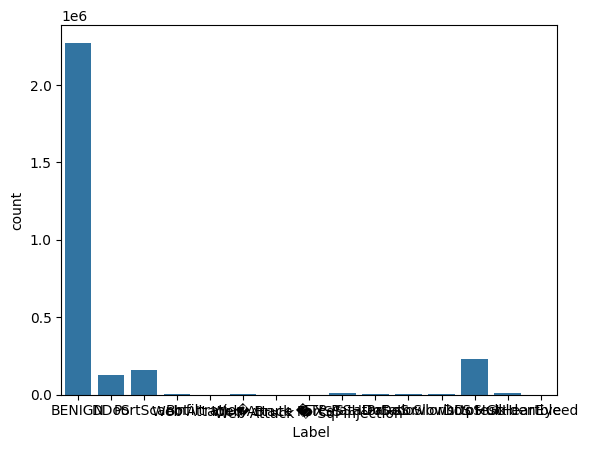

In [57]:
sns.countplot(data=df, x=df[" Label"])

plt.show()

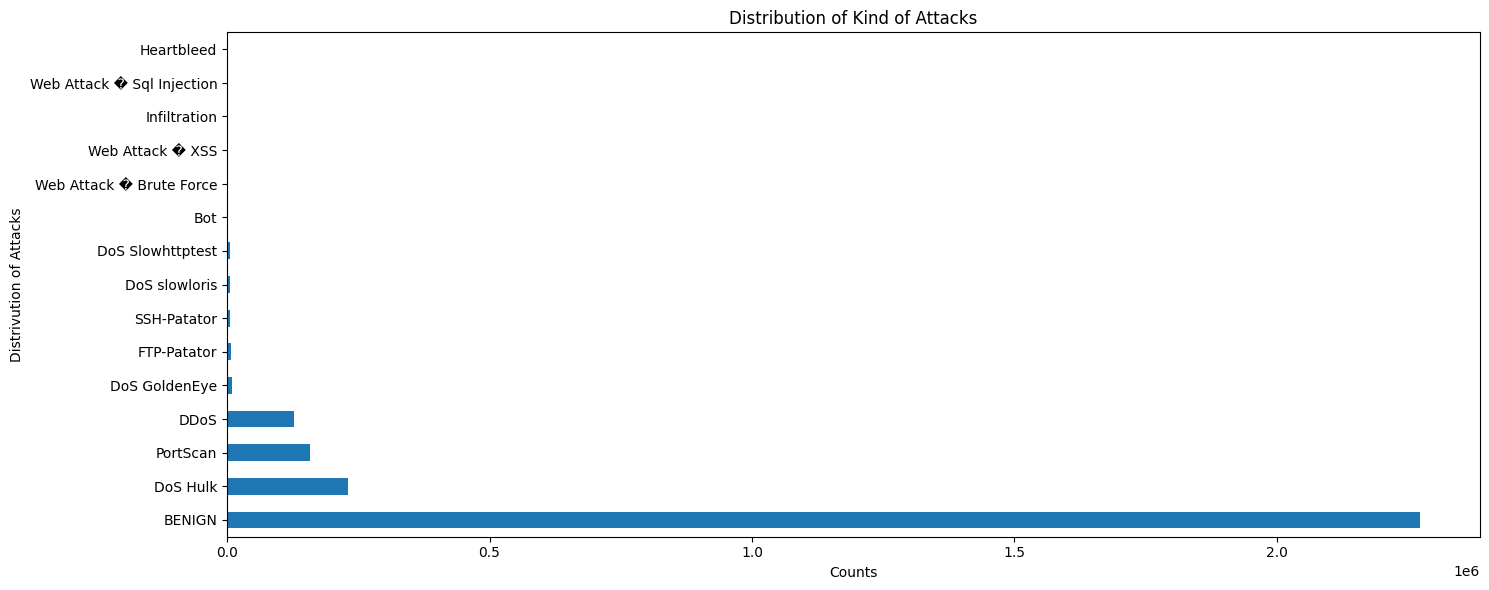

In [58]:
counts = df[" Label"].value_counts()

plt.figure(figsize=(15, 6))
counts.plot(kind='barh')


plt.title("Distribution of Kind of Attacks")
plt.xlabel("Counts")
plt.ylabel("Distrivution of Attacks")

plt.tight_layout()
plt.show()

In [59]:
df.head(100)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,80,28466,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
96,443,101027175,14,12,1029,991,460,0,73.5,150.040379,...,32,1048172.0,1296391.188,1964859,131485,49400000.0,12900000.0,58500000,40300000,BENIGN
97,53,330,2,2,74,198,37,37,37.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN
98,53,221,2,2,74,106,37,37,37.0,0.000000,...,20,0.0,0.000,0,0,0.0,0.0,0,0,BENIGN


c:\Users\Masrafi Siam\OneDrive\Desktop\NIDS-Draft\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


<Axes: xlabel=' Flow Duration', ylabel='Count'>

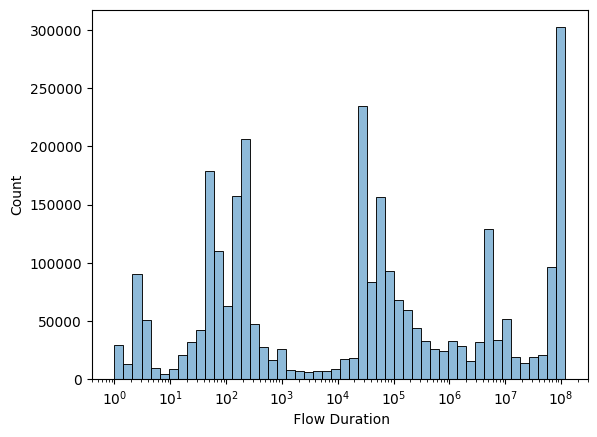

In [60]:
# Limit to reasonable range and use log scale
sns.histplot(data=df, x=" Flow Duration", bins=50, kde=True, 
             log_scale=True,  # This helps with the huge range
             stat='count')
 

In [61]:
# Check unique values in your data
print(df[" Flow Duration"].value_counts().head(20))

# Check if all values are multiples of 0.01
print(df[" Flow Duration"].unique()[:20])

# Check data range
print(df[" Flow Duration"].describe())

 Flow Duration
3     90197
4     50892
1     29223
49    25868
48    24284
43    15185
44    14352
2     12866
50     8909
54     8718
42     8195
53     7926
45     7865
55     7753
51     7368
52     7153
5      7132
47     7051
56     6239
63     5988
Name: count, dtype: int64
[   3  109   52   34 1022    4   42    1   54  154  118  239    5  737
  276  105   66   68   48   16]
count    2.830743e+06
mean     1.478566e+07
std      3.365374e+07
min     -1.300000e+01
25%      1.550000e+02
50%      3.131600e+04
75%      3.204828e+06
max      1.200000e+08
Name:  Flow Duration, dtype: float64


In [62]:
print(df[" Flow Duration"].describe())

count    2.830743e+06
mean     1.478566e+07
std      3.365374e+07
min     -1.300000e+01
25%      1.550000e+02
50%      3.131600e+04
75%      3.204828e+06
max      1.200000e+08
Name:  Flow Duration, dtype: float64


In [63]:
df.drop(" Fwd Header Length.1", axis=1, inplace=True)

In [64]:
rename_map = {

    " Destination Port": "dst_port",
    " Flow Duration": "flow_duration",

    " Total Fwd Packets": "tot_fwd_pkts",
    " Total Backward Packets": "tot_bwd_pkts",

    "Total Length of Fwd Packets": "totlen_fwd_pkts",
    " Total Length of Bwd Packets": "totlen_bwd_pkts",

    " Fwd Packet Length Max": "fwd_pkt_len_max",
    " Fwd Packet Length Min": "fwd_pkt_len_min",
    " Fwd Packet Length Mean": "fwd_pkt_len_mean",
    " Fwd Packet Length Std": "fwd_pkt_len_std",

    "Bwd Packet Length Max": "bwd_pkt_len_max",
    " Bwd Packet Length Min": "bwd_pkt_len_min",
    " Bwd Packet Length Mean": "bwd_pkt_len_mean",
    " Bwd Packet Length Std": "bwd_pkt_len_std",

    "Flow Bytes/s": "flow_byts_s",
    " Flow Packets/s": "flow_pkts_s",

    " Flow IAT Mean": "flow_iat_mean",
    " Flow IAT Std": "flow_iat_std",
    " Flow IAT Max": "flow_iat_max",
    " Flow IAT Min": "flow_iat_min",

    "Fwd IAT Total": "fwd_iat_tot",
    " Fwd IAT Mean": "fwd_iat_mean",
    " Fwd IAT Std": "fwd_iat_std",
    " Fwd IAT Max": "fwd_iat_max",
    " Fwd IAT Min": "fwd_iat_min",

    "Bwd IAT Total": "bwd_iat_tot",
    " Bwd IAT Mean": "bwd_iat_mean",
    " Bwd IAT Std": "bwd_iat_std",
    " Bwd IAT Max": "bwd_iat_max",
    " Bwd IAT Min": "bwd_iat_min",

    "Fwd PSH Flags": "fwd_psh_flags",
    " Bwd PSH Flags": "bwd_psh_flags",
    " Fwd URG Flags": "fwd_urg_flags",
    " Bwd URG Flags": "bwd_urg_flags",

    " Fwd Header Length": "fwd_header_len",
    " Bwd Header Length": "bwd_header_len",

    "Fwd Packets/s": "fwd_pkts_s",
    " Bwd Packets/s": "bwd_pkts_s",

    " Min Packet Length": "pkt_len_min",
    " Max Packet Length": "pkt_len_max",
    " Packet Length Mean": "pkt_len_mean",
    " Packet Length Std": "pkt_len_std",
    " Packet Length Variance": "pkt_len_var",

    "FIN Flag Count": "fin_flag_cnt",
    " SYN Flag Count": "syn_flag_cnt",
    " RST Flag Count": "rst_flag_cnt",
    " PSH Flag Count": "psh_flag_cnt",
    " ACK Flag Count": "ack_flag_cnt",
    " URG Flag Count": "urg_flag_cnt",
    " CWE Flag Count": "cwr_flag_count",
    " ECE Flag Count": "ece_flag_cnt",

    " Down/Up Ratio": "down_up_ratio",
    " Average Packet Size": "pkt_size_avg",

    " Avg Fwd Segment Size": "fwd_seg_size_avg",
    " Avg Bwd Segment Size": "bwd_seg_size_avg",

    # Duplicate column — don't use it
    # " Fwd Header Length.1"

    "Fwd Avg Bytes/Bulk": "fwd_byts_b_avg",
    " Fwd Avg Packets/Bulk": "fwd_pkts_b_avg",
    " Fwd Avg Bulk Rate": "fwd_blk_rate_avg",

    " Bwd Avg Bytes/Bulk": "bwd_byts_b_avg",
    " Bwd Avg Packets/Bulk": "bwd_pkts_b_avg",
    "Bwd Avg Bulk Rate": "bwd_blk_rate_avg",

    "Subflow Fwd Packets": "subflow_fwd_pkts",
    " Subflow Fwd Bytes": "subflow_fwd_byts",
    " Subflow Bwd Packets": "subflow_bwd_pkts",
    " Subflow Bwd Bytes": "subflow_bwd_byts",

    "Init_Win_bytes_forward": "init_fwd_win_byts",
    " Init_Win_bytes_backward": "init_bwd_win_byts",

    " act_data_pkt_fwd": "fwd_act_data_pkts",
    " min_seg_size_forward": "fwd_seg_size_min",

    "Active Mean": "active_mean",
    " Active Std": "active_std",
    " Active Max": "active_max",
    " Active Min": "active_min",

    "Idle Mean": "idle_mean",
    " Idle Std": "idle_std",
    " Idle Max": "idle_max",
    " Idle Min": "idle_min",

    " Label": "label"
}

In [65]:
df.rename(columns=rename_map, inplace=True)

In [66]:
with open("columns_renamed_CICIDS2017.txt", "w") as f:
    for col in df.columns:
        f.write(col + "\n")

In [67]:
X = df.drop("label", axis=1)
y = df["label"]

In [68]:
y.describe()

count     2830743
unique         15
top        BENIGN
freq      2273097
Name: label, dtype: object

In [69]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2830743 entries, 0 to 2830742
Series name: label
Non-Null Count    Dtype 
--------------    ----- 
2830743 non-null  object
dtypes: object(1)
memory usage: 21.6+ MB


In [73]:
counts = y.value_counts()
percentage = y.value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    "count" : counts,
    "parcentage" : percentage
})

print(distribution)

                              count  parcentage
label                                          
BENIGN                      2273097   80.300366
DoS Hulk                     231073    8.162981
PortScan                     158930    5.614427
DDoS                         128027    4.522735
DoS GoldenEye                 10293    0.363615
FTP-Patator                    7938    0.280421
SSH-Patator                    5897    0.208320
DoS slowloris                  5796    0.204752
DoS Slowhttptest               5499    0.194260
Bot                            1966    0.069452
Web Attack � Brute Force       1507    0.053237
Web Attack � XSS                652    0.023033
Infiltration                     36    0.001272
Web Attack � Sql Injection       21    0.000742
Heartbleed                       11    0.000389


In [74]:
y_binary = y.apply(
    lambda x: 0 if x== "BENIGN" else 1
)

In [75]:
print(y_binary.value_counts())

label
0    2273097
1     557646
Name: count, dtype: int64


In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_binary)

In [79]:
print(X.shape)

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude="number").columns)

(2830743, 77)

Non-numeric columns:
Index([], dtype='object')


In [81]:
missing = X.isna().sum()

print(missing[missing>0])

print("\nTotal missing values:", X.isna().sum().sum())

flow_byts_s    1358
dtype: int64

Total missing values: 1358
